In [ ]:
# ============================================================
# SETUP - Run this cell first
# ============================================================
!git clone https://github.com/tatipar/temporalgnn-nids.git
import sys
sys.path.append('/content/temporalgnn-nids/code/python')

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/nids-mitre/')

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.1 MB/s eta 0:00:00


In [ ]:
import os
import glob
import re
import numpy as np
import pandas as pd
import random
import json
import time
from math import pi

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.loader import DataLoader


In [ ]:
from utils.datasets      import NF_IDS_Dataset
from utils.models        import SimpleMLP, EdgeGRU_Baseline, StaticGNN_Identity, ST_GNN_Identity
from utils.metrics       import calculate_metrics_gnn
from utils.training      import evaluate
from utils.visualization import plot_comparison, plot_radar_chart, MODEL_COLORS
from utils.evaluation import evaluate_test1, generate_summary_table


# Functions

## Evaluate test1

## Summary table

# Auxiliary

In [15]:
ROOT_PATH = "./dataset_processed"

In [16]:
# Instantiate Dataset (Only reads file names)
test1_dataset = NF_IDS_Dataset(root_dir=ROOT_PATH, split='test')

print(f"Test1 size: {len(test1_dataset)}")

# Instantiate DataLoader (Load manager)
test1_loader = DataLoader(test1_dataset, batch_size=1, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=False)



Test1 size: 429


In [17]:
BASE_RESULTS_PATH = "./results_earlystopping/"

RESULTS_TEST_DIRNAME="test1_results"
TEST1_DIR = os.path.join(BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME)

MODEL_NAME_MAPPING = {
    'SimpleMLP_BiasOn': 'Simple MLP',
    'EdgeGRU_BiasOn': 'Edge GRU',
    'StaticGNN_BiasOn_robust_Identity': 'Static GNN',
    'ST_GNN_BiasOn_robust_Identity_clone': 'ST-GNN (Ours)'
}


In [18]:
sns.set_theme(style="whitegrid")

colors = {
    "Simple MLP": "#95a5a6",   # Gray
    "Edge GRU": "#3498db",   # Blue
    "Static GNN": "#e67e22",     # Orange
    "ST-GNN (Ours)": "#2ecc71" # Green
}


# Main

In [19]:
# --- PARAMETERS ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

EPOCHS = 60
BATCH_STEPS = 10 # backprop every 10 snapshots (sequence)
LR = 0.005
POS_WEIGHT = 2.0

NODE_DIM = 16   # Features dummy (1s)
EDGE_DIM = 32   # 20 numeric + 7 dst_port + 5 protocol
HIDDEN_DIM = 32
DROPOUT = 0.2
BIAS_VALUE = -2.9968

#PROB_THRESHOLD = 0.5



Using device: cpu


In [20]:
model_config = {
    "model_name": None,
    "type": None,
    "model_params": {
        "node_dim": NODE_DIM,
        "edge_dim": EDGE_DIM,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "output_bias_init": BIAS_VALUE
    },
    #"prob_threshold": PROB_THRESHOLD,
    "extra_params": {
        "epochs": EPOCHS,
        "batch_steps": BATCH_STEPS,
        "pos_weight": POS_WEIGHT,
        "learning_rate": LR
    }
}

In [21]:
pairs = [(SimpleMLP, "SimpleMLP_BiasOn"),
          (EdgeGRU_Baseline, "EdgeGRU_BiasOn"),
          (StaticGNN_Identity, "StaticGNN_BiasOn_robust_Identity"),
          (ST_GNN_Identity, "ST_GNN_BiasOn_robust_Identity_clone")]

In [ ]:
all_results_dfs = []
for i, (mclass, exp_name) in enumerate(pairs):
    current_df = evaluate_test1(mclass, model_config, test1_loader, exp_name, DEVICE, BASE_RESULTS_PATH, RESULTS_TEST_DIRNAME, True)
    if not current_df.empty:
        all_results_dfs.append(current_df)

    if i < len(pairs) - 1: # Only print separators if it's not the last iteration
        print("="*70)
        print("\n")
        print("="*70)

if all_results_dfs:
    final_combined_df = pd.concat(all_results_dfs, ignore_index=True)
    # Extract the base model name by splitting at '_seed' and then apply the mapping
    final_combined_df['model'] = final_combined_df['model_name'].apply(lambda x: MODEL_NAME_MAPPING.get(x.split('_seed')[0], x.split('_seed')[0]))
    print("\nAll evaluation results combined")
else:
    print("No evaluation results were generated.")


Evaluating: SimpleMLP_BiasOn_seed42
 Precision: 0.0040 | Recall: 0.0006 | F1: 0.0010 | F2: 0.0007 | AUC-PR: 0.0462 | AUC-ROC: 0.8121 | FPR: 0.0026

------------------------------------------------------------

Evaluating: SimpleMLP_BiasOn_seed123
 Precision: 0.0101 | Recall: 0.0026 | F1: 0.0042 | F2: 0.0031 | AUC-PR: 0.0460 | AUC-ROC: 0.8099 | FPR: 0.0047

------------------------------------------------------------

Evaluating: SimpleMLP_BiasOn_seed777
 Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | F2: 0.0000 | AUC-PR: 0.0591 | AUC-ROC: 0.8461 | FPR: 0.0008

------------------------------------------------------------

Evaluating: SimpleMLP_BiasOn_seed2024
 Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | F2: 0.0000 | AUC-PR: 0.0597 | AUC-ROC: 0.8393 | FPR: 0.0011

------------------------------------------------------------

Evaluating: SimpleMLP_BiasOn_seed99
 Precision: 0.0043 | Recall: 0.0006 | F1: 0.0010 | F2: 0.0007 | AUC-PR: 0.0439 | AUC-ROC: 0.8040 | FPR: 0.0025

-------

In [ ]:
generate_summary_table(final_combined_df)


 SUMMARY TABLE (Mean ± Std)
              Precision          Recall              F1              F2  \
                   mean     std    mean     std    mean     std    mean   
model                                                                     
Simple MLP       0.0037  0.0042  0.0008  0.0011  0.0012  0.0017  0.0009   
Edge GRU         0.1031  0.0289  0.4950  0.1911  0.1620  0.0311  0.2612   
Static GNN       0.4926  0.1050  0.6944  0.0509  0.5674  0.0719  0.6329   
ST-GNN (Ours)    0.6910  0.0625  0.7284  0.0795  0.7041  0.0319  0.7174   

                       AUC-PR         AUC-ROC             FPR          \
                  std    mean     std    mean     std    mean     std   
model                                                                   
Simple MLP     0.0013  0.0510  0.0078  0.8223  0.0190  0.0024  0.0015   
Edge GRU       0.0552  0.0939  0.0150  0.8745  0.0100  0.0872  0.0435   
Static GNN     0.0335  0.4257  0.0423  0.9320  0.0065  0.0147  0.0089   
ST-GNN 

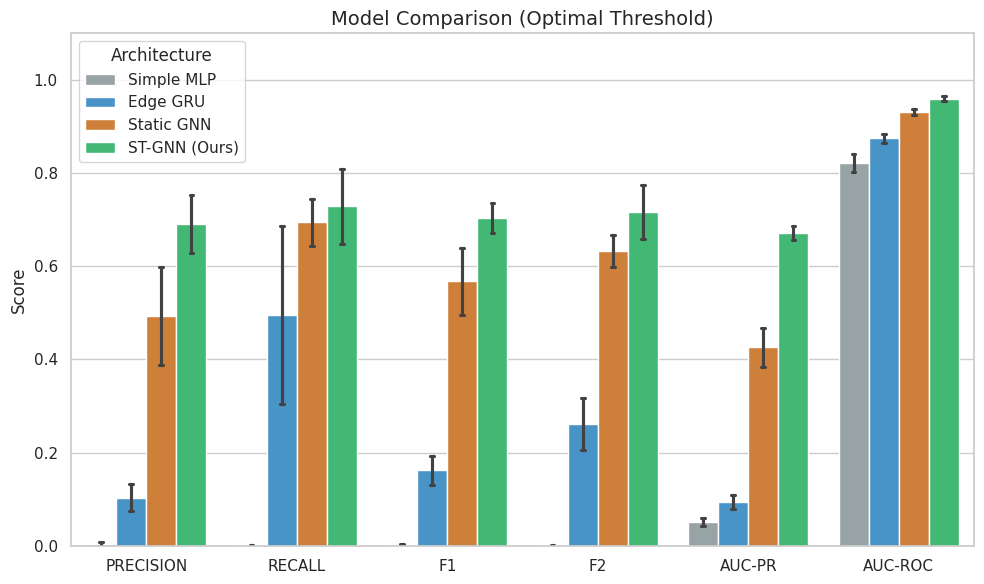

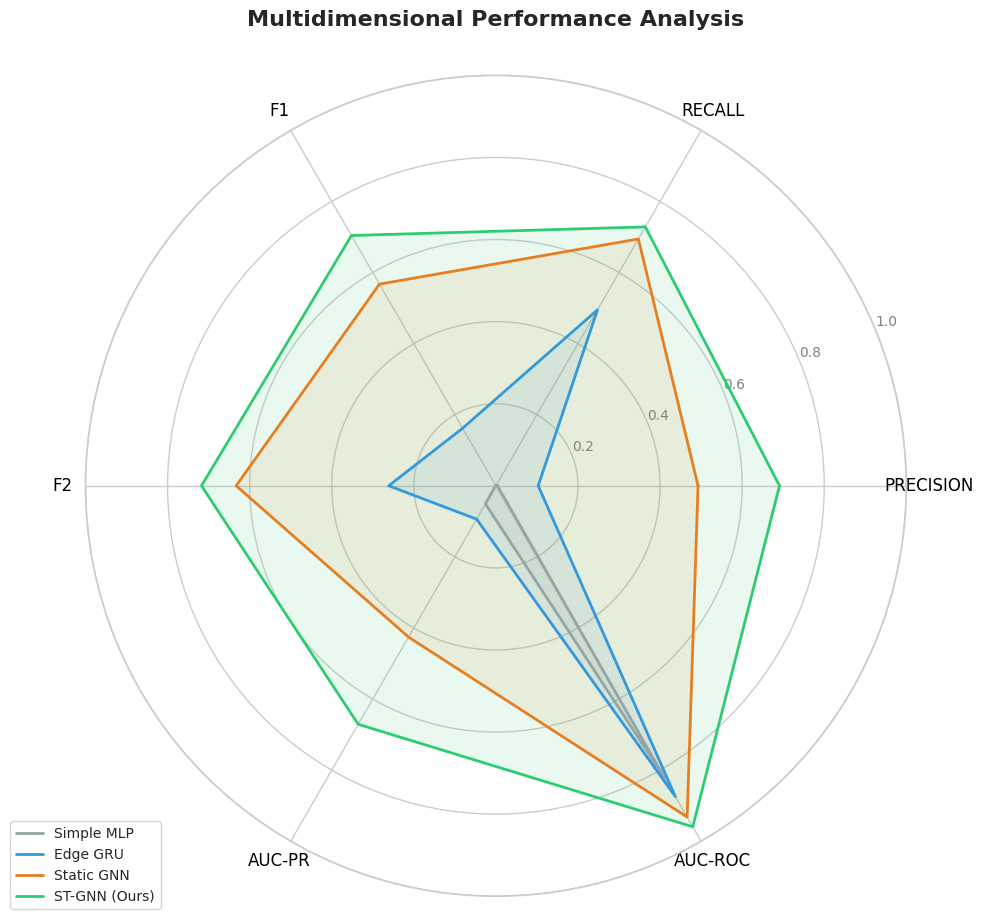

In [ ]:
plot_comparison(final_combined_df, TEST1_DIR)

plot_radar_chart(final_combined_df, TEST1_DIR)